# Siemens HV-Reden – N-Gram Analyse 2022–2026
**Masterarbeit: Data Availability & KI-Wahrnehmung im Zeitverlauf**

Dieses Notebook analysiert die Hauptversammlungsreden von Siemens:
- **CEO** (Roland Busch): 2022, 2026  
- **AR-Vorsitz** (Jim Hagemann Snabe): 2022, 2025  

> **Hinweis:** Fehlende Jahre (2023, 2024) können ergänzt werden – das Notebook erkennt sie automatisch.

---
### Analysierte Terme
| 1-Gramme | 2-Gramme |
|---|---|
| KI, AI, Daten, Data | Künstliche Intelligenz, Artificial Intelligence, Machine Learning, Digitale Zwillinge, Generative AI |

In [21]:
# ─── 1. IMPORTS & KONFIGURATION ───────────────────────────────────────────────
import re
import subprocess
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Matplotlib-Stil ──
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'figure.dpi':         150,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
})

# ── Farben (konsistent über alle Charts) ──
C = {
    'ceo':        '#1A5F9E',   # Dunkelblau  = CEO-Reden
    'ar':         '#D95F2B',   # Orange-Rot  = AR-Vorsitz-Reden
    'ki':         '#1A5F9E',
    'ai':         '#5B8FCE',
    'daten':      '#D95F2B',
    'data':       '#E8956D',
    'künstliche intelligenz': '#2BAE66',
    'machine learning':       '#7B4FA6',
    'digitale zwillinge':     '#B8860B',
    'generative ai':          '#C0392B',
    'generative ki':          '#E74C3C',
}

# ── Analyse-Terme ──
TERMS_1GRAM = ['ki', 'ai', 'daten', 'data']
TERMS_2GRAM = [
    'künstliche intelligenz',
    'artificial intelligence',
    'machine learning',
    'digitale zwillinge',
    'generative ai',
    'generative ki',
    'deep learning',
]
ALL_TERMS = TERMS_1GRAM + TERMS_2GRAM

NORM_FACTOR = 1000   # Vorkommen pro N Wörter

print('✓ Setup abgeschlossen')
print(f'  Analysierte 1-Gramme: {TERMS_1GRAM}')
print(f'  Analysierte 2-Gramme: {TERMS_2GRAM}')

✓ Setup abgeschlossen
  Analysierte 1-Gramme: ['ki', 'ai', 'daten', 'data']
  Analysierte 2-Gramme: ['künstliche intelligenz', 'artificial intelligence', 'machine learning', 'digitale zwillinge', 'generative ai', 'generative ki', 'deep learning']


In [20]:
# ─── 2. PDF-PFADE ─────────────────────────────────────────────────────────────
PDF_BASE = Path('/Users/tgumpp/Documents/MasterThesis/dax40-ai-analysis/data/raw')

DOCUMENTS = [

    # ── ALLIANZ ───────────────────────────────────────────────────────────────
    ('Allianz/2022/de-rede-baete-hv-2022.pdf',           2022, 'Oliver Bäte',          'ceo'),
    ('Allianz/2022/de-rede-diekmann-hv-2022.pdf',        2022, 'Michael Diekmann',      'ar'),
    ('Allianz/2023/de-rede-baete-hv-2023.pdf',           2023, 'Oliver Bäte',          'ceo'),
    ('Allianz/2023/de-rede-diekmann-hv-2023.pdf',        2023, 'Michael Diekmann',      'ar'),
    ('Allianz/2024/de-rede-baete-hv-2024.pdf',           2024, 'Oliver Bäte',          'ceo'),
    ('Allianz/2024/de-rede-diekmann-hv-2024.pdf',        2024, 'Michael Diekmann',      'ar'),
    ('Allianz/2025/de-rede-baete-hv-2025.pdf',           2025, 'Oliver Bäte',          'ceo'),
    ('Allianz/2025/de-rede-diekmann-hv-2025.pdf',        2025, 'Michael Diekmann',      'ar'),

    # ── GEA ───────────────────────────────────────────────────────────────────
    ('GEA/2022/speech of klaus helmrich - de.pdf',       2022, 'Klaus Helmrich',        'ar'),
    ('GEA/2022/speech-stefan-klebert-agm-2022-de.pdf',   2022, 'Stefan Klebert',        'ceo'),
    ('GEA/2023/letter-of-the-chairman-of-the-supervisory-board-agm-2023-de.pdf',
     2023, 'Klaus Helmrich',        'ar'),
    ('GEA/2023/speech-stefan-klebert-ceo-gea-agm-2023-de.pdf',
     2023, 'Stefan Klebert',        'ceo'),
    ('GEA/2024/brief-kemp-DE.pdf',                       2024, 'Dr. Kemp',              'ar'),
    ('GEA/2024/gea-hv-2024-rede-stefan-klebert-ceo.pdf', 2024, 'Stefan Klebert',        'ceo'),
    ('GEA/2025/agm-gea-2025-speech-stefan-klebert-de.pdf',
     2025, 'Stefan Klebert',        'ceo'),
    ('GEA/2025/letter-from-chairman-de.pdf',             2025, 'Dr. Kemp',              'ar'),
    ('GEA/2026/letter-from-the-chairman-de.pdf',         2026, 'Dr. Kemp',              'ar'),

    # ── MERCEDES ──────────────────────────────────────────────────────────────
    ('Mercedes/2022/mercedes-benz-ir-hv-2022-rede-aufsichtsratsvorsitzender-bernd-pischetsrieder.pdf',
     2022, 'Bernd Pischetsrieder',  'ar'),
    ('Mercedes/2022/mercedes-benz-ir-hv-2022-rede-vorstandsvorsitzender-ola-kaellenius.pdf',
     2022, 'Ola Källenius',         'ceo'),
    ('Mercedes/2023/mercedes-benz-ir-hv-2023-rede-aufsichtsratsvorsitzender-bernd-pischetsrieder.pdf',
     2023, 'Bernd Pischetsrieder',  'ar'),
    ('Mercedes/2023/mercedes-benz-ir-hv-2023-rede-vorstandsvorsitzender-ola-kaellenius.pdf',
     2023, 'Ola Källenius',         'ceo'),
    ('Mercedes/2024/mercedes-benz-ir-hv-2024-rede-aufsichtsratsvorsitzender-bernd-pischetsrieder.pdf',
     2024, 'Bernd Pischetsrieder',  'ar'),
    ('Mercedes/2024/mercedes-benz-ir-hv-2024-rede-vorstandsvorsitzender-ola-kaellenius.pdf',
     2024, 'Ola Källenius',         'ceo'),
    ('Mercedes/2025/mercedes-benz-ir-hv-2025-rede-aufsichtsratsvorsitzender-martin-brudermueller.pdf',
     2025, 'Martin Brudermüller',   'ar'),
    ('Mercedes/2025/mercedes-benz-ir-hv-2025-rede-vorstandsvorsitzender-ola-kaellenius.pdf',
     2025, 'Ola Källenius',         'ceo'),

    # ── MUNICH RE (Englisch) ───────────────────────────────────────────────────
    ('MunichRe/2022/AGM_2022_Report_Wenning_EN.pdf',     2022, 'Joachim Wenning',       'ceo'),
    ('MunichRe/2022/AGM_2022_Report_vBomhard_EN.pdf',    2022, 'Nikolaus von Bomhard',  'ar'),
    ('MunichRe/2023/HV23-Bericht-Wenning-EN.pdf',        2023, 'Joachim Wenning',       'ceo'),
    ('MunichRe/2023/HV23-Bericht-vBomhard-EN.pdf',       2023, 'Nikolaus von Bomhard',  'ar'),
    ('MunichRe/2024/HV24-Bericht-CEO-EN.pdf',            2024, 'Joachim Wenning',       'ceo'),
    ('MunichRe/2024/HV24-Bericht-ARV-EN.pdf',            2024, 'Nikolaus von Bomhard',  'ar'),
    ('MunichRe/2025/HV25-Bericht-Vorstandsvorsitzender-EN.pdf',
     2025, 'Joachim Wenning',       'ceo'),
    ('MunichRe/2025/HV25-Bericht-ARV-EN.pdf',            2025, 'Nikolaus von Bomhard',  'ar'),

    # ── SAP ───────────────────────────────────────────────────────────────────
    ('SAP/2022/SAP SE Hauptversammlung 2022_ Rede des Vorstandssprechers.pdf',
     2022, 'Christian Klein',       'ceo'),
    ('SAP/2022/Schreiben von Prof. Dr. h. c. mult. Hasso Plattner, Vorsitzender des Aufsichtsrats der SAP SE-2.pdf',
     2022, 'Hasso Plattner',        'ar'),
    ('SAP/2023/SAP SE Hauptversammlung 2023_ Rede des Vorstandssprechers.pdf',
     2023, 'Christian Klein',       'ceo'),
    ('SAP/2023/Schreiben von Prof. Dr. h. c. mult. Hasso Plattner, Vorsitzender des Aufsichtsrats der SAP SE.pdf',
     2023, 'Hasso Plattner',        'ar'),
    ('SAP/2024/SAP SE Hauptversammlung 2024_ Rede des Vorstandssprechers.pdf',
     2024, 'Christian Klein',       'ceo'),
    ('SAP/2024/SAP SE Hauptversammlung 2024_ Schreiben von Prof. Dr. h. c. mult. Hasso Plattner.pdf',
     2024, 'Hasso Plattner',        'ar'),
    ('SAP/2025/Rede des Vorstandsvorsitzenden 2025.pdf', 2025, 'Christian Klein',       'ceo'),
    ('SAP/2025/Brief des Aufsichtsratsvorsitzenden 2025.pdf',
     2025, 'Hasso Plattner',        'ar'),

    # ── SIEMENS (Ordnername Kleinschreibung!) ──────────────────────────────────
    ('siemens/2022/Roland-Busch-HV-Rede-2022-DE.pdf',    2022, 'Roland Busch',          'ceo'),
    ('siemens/2022/HV-Rede-2022-Snabe-DE.pdf',           2022, 'Jim H. Snabe',           'ar'),
    ('siemens/2023/Roland-Busch-HV-Rede-2023-DE.pdf',    2023, 'Roland Busch',          'ceo'),
    ('siemens/2023/HV-Rede-2023-JHS-DE.pdf',             2023, 'Jim H. Snabe',           'ar'),
    ('siemens/2024/HV-Rede-2024-Roland-Busch-Presseformat-DE.pdf',
     2024, 'Roland Busch',          'ceo'),
    ('siemens/2024/HV-Rede-2024-Werner-Brandt-Presseformat-DE.pdf',
     2024, 'Werner Brandt',         'ar'),
    ('siemens/2025/HV-Rede-2025-Roland-Busch-Presseformat-DE.pdf',
     2025, 'Roland Busch',          'ceo'),
    ('siemens/2025/HV-Rede-2025-Jim-Hagemann-Snabe-Presseformat-DE.pdf',
     2025, 'Jim H. Snabe',           'ar'),
    ('siemens/2026/HV-Rede-RB-HV2026.pdf',               2026, 'Roland Busch',          'ceo'),
    ('siemens/2026/HV-Rede-JHS-HV2026.pdf',              2026, 'Jim H. Snabe',           'ar'),

    # ── TELEKOM ───────────────────────────────────────────────────────────────
    ('Telekom/2022/dl-220407-rede-hoettges.pdf',         2022, 'Timotheus Höttges',     'ceo'),
    ('Telekom/2022/dl-2022-bericht-aufsichtsrat.pdf',    2022, 'AR-Vorsitz',            'ar'),
    ('Telekom/2023/dl-230405-rede-hoettges.pdf',         2023, 'Timotheus Höttges',     'ceo'),
    ('Telekom/2023/dl-2023-bericht-aufsichtsrat.pdf',    2023, 'AR-Vorsitz',            'ar'),
    ('Telekom/2024/dl-230410-rede-hoettges-hv-dtag.pdf', 2024, 'Timotheus Höttges',     'ceo'),
    ('Telekom/2024/dl-2024-bericht-aufsichtsrat.pdf',    2024, 'AR-Vorsitz',            'ar'),
    ('Telekom/2025/dl-250409-rede-hoettges-hv-dtag.pdf', 2025, 'Timotheus Höttges',     'ceo'),
    ('Telekom/2025/dl-2025-bericht-aufsichtsrat.pdf',    2025, 'AR-Vorsitz',            'ar'),
    ('Telekom/2026/dl-2026-bericht-aufsichtsrat.pdf',    2026, 'AR-Vorsitz',            'ar'),
]

# Verfügbarkeit prüfen
print('Dokument-Verfügbarkeit:')
missing, found = [], []
for fname, year, speaker, role in DOCUMENTS:
    path = PDF_BASE / fname
    if path.exists():
        found.append(fname)
    else:
        missing.append((fname.split('/')[0], year, role, fname.split('/')[-1]))

print(f'  ✓ Gefunden : {len(found)}')
print(f'  ✗ Fehlend  : {len(missing)}')
if missing:
    print('\n  Fehlende Dateien:')
    for company, year, role, name in missing:
        print(f'    {company:12} {year} {role.upper():3}  {name}')

Dokument-Verfügbarkeit:
  ✓ Gefunden : 60
  ✗ Fehlend  : 0


In [23]:
# ─── 3. TEXT-EXTRAKTION ───────────────────────────────────────────────────────
def extract_text(pdf_path: Path) -> str:
    """
    Extrahiert Text aus PDF via pdftotext.
    -layout bewahrt die Textstruktur und behandelt Umlaute korrekt.
    Fallback: pdfplumber (Python-native, kein CLI nötig).
    """
    # Primär: pdftotext (CLI, beste Qualität für DE-Text)
    try:
        result = subprocess.run(
            ['pdftotext', '-layout', str(pdf_path), '-'],
            capture_output=True, text=True, timeout=30
        )
        if result.returncode == 0 and result.stdout.strip():
            return result.stdout
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass

    # Fallback: pdfplumber
    try:
        import pdfplumber
        with pdfplumber.open(str(pdf_path)) as pdf:
            return '\n'.join(p.extract_text() or '' for p in pdf.pages)
    except Exception as e:
        print(f'  Fehler bei {pdf_path.name}: {e}')
        return ''


def clean_text(raw: str) -> str:
    """
    Bereinigt extrahierten PDF-Text für die N-Gram-Analyse.
    Wichtig: Silbentrennung, Seitenzahlen, Kopf-/Fußzeilen entfernen.
    """
    # Silbentrennungen am Zeilenende zusammenführen
    text = re.sub(r'-\n', '', raw)
    # Seitenzahlen (z.B. "Seite 3 von 17")
    text = re.sub(r'Seite\s+\d+\s+von\s+\d+', '', text, flags=re.IGNORECASE)
    # Kopfzeile "Rede von ... am ..."
    text = re.sub(r'Rede von .{5,60} \d{4}\n', '\n', text)
    # Seitenumbrüche (\x0c)
    text = text.replace('\x0c', '\n')
    # Mehrfach-Leerzeichen & -Zeilenumbrüche
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


# ── Alle Dokumente laden ──
records = []
for fname, year, speaker, role in DOCUMENTS:
    path = PDF_BASE / fname
    if not path.exists():
        continue
    raw  = extract_text(path)
    text = clean_text(raw)
    wc   = len(text.split())
    records.append({
        'filename': fname,
        'company':  fname.split('/')[0],
        'year':     year,
        'speaker':  speaker,
        'role':     role,
        'text':     text,
        'wordcount': wc,
    })
    print(f'✓ {year} {role.upper():3} | {speaker:25} | {wc:>5} Wörter')

corpus = pd.DataFrame(records)
print(f'\nCorpus: {len(corpus)} Dokumente | {corpus["wordcount"].sum():,} Wörter gesamt')

✓ 2022 CEO | Oliver Bäte               |  3446 Wörter
✓ 2022 AR  | Michael Diekmann          |     0 Wörter
✓ 2023 CEO | Oliver Bäte               |  4031 Wörter
✓ 2023 AR  | Michael Diekmann          |  4069 Wörter
✓ 2024 CEO | Oliver Bäte               |  3496 Wörter
✓ 2024 AR  | Michael Diekmann          |  2355 Wörter
✓ 2025 CEO | Oliver Bäte               |  4041 Wörter
✓ 2025 AR  | Michael Diekmann          |  2426 Wörter
✓ 2022 AR  | Klaus Helmrich            |  1437 Wörter
✓ 2022 CEO | Stefan Klebert            |  4333 Wörter
✓ 2023 AR  | Klaus Helmrich            |  1098 Wörter
✓ 2023 CEO | Stefan Klebert            |  3870 Wörter
✓ 2024 AR  | Dr. Kemp                  |  1474 Wörter
✓ 2024 CEO | Stefan Klebert            |  3421 Wörter
✓ 2025 CEO | Stefan Klebert            |  3587 Wörter
✓ 2025 AR  | Dr. Kemp                  |  2522 Wörter
✓ 2026 AR  | Dr. Kemp                  |  2353 Wörter
✓ 2022 AR  | Bernd Pischetsrieder      |     7 Wörter
✓ 2022 CEO | Ola Källenius  

In [24]:
# ─── 4. N-GRAM ZÄHLUNG ────────────────────────────────────────────────────────
def count_term(text: str, term: str) -> int:
    """
    Zählt exakte Vorkommen eines Terms mit Wortgrenzen.
    \\b erkennt Wortgrenzen auch bei Umlauten korrekt.
    
    Wichtig: 'ki' soll nicht 'Risiko' matchen → Wortgrenze ist entscheidend.
    """
    if not text or not term:
        return 0
    pattern = r'\b' + re.escape(term) + r'\b'
    return len(re.findall(pattern, text, re.IGNORECASE))


# Frequenz-DataFrame aufbauen
freq_rows = []
for _, doc in corpus.iterrows():
    for term in ALL_TERMS:
        raw_count  = count_term(doc['text'], term)
        norm_count = (raw_count / doc['wordcount']) * NORM_FACTOR if doc['wordcount'] > 0 else 0
        freq_rows.append({
            'company':        doc['company'],
            'year':           doc['year'],
            'speaker':        doc['speaker'],
            'role':           doc['role'],
            'role_label':     'CEO' if doc['role'] == 'ceo' else 'AR-Vorsitz',
            'term':           term,
            'term_type':      '1-Gramm' if term in TERMS_1GRAM else '2-Gramm',
            'count_raw':      raw_count,
            'count_norm':     round(norm_count, 4),
            'wordcount':      doc['wordcount'],
        })

freq = pd.DataFrame(freq_rows)

# Übersichtstabelle
pivot = freq[freq['count_raw'] > 0].pivot_table(
    index=['term', 'term_type'],
    columns=['year', 'role_label'],
    values='count_raw',
    aggfunc='sum',
    fill_value=0
)
print('Rohe Häufigkeiten (nur Terme mit mind. 1 Treffer):')
pivot

Rohe Häufigkeiten (nur Terme mit mind. 1 Treffer):


year                              2022       2023           2024      \
role_label                         CEO AR-Vorsitz CEO AR-Vorsitz CEO   
term                    term_type                                      
ai                      1-Gramm      0          0   0          0   6   
artificial intelligence 2-Gramm      0          1   0          1   0   
data                    1-Gramm      2          2   0          0   0   
daten                   1-Gramm      3          0  10          2  13   
digitale zwillinge      2-Gramm      0          0   2          0   4   
generative ki           2-Gramm      0          0   0          0   4   
ki                      1-Gramm      0          0   2          5  56   
künstliche intelligenz  2-Gramm      1          0  10          3  14   

year                                    2025           2026      
role_label                        AR-Vorsitz CEO AR-Vorsitz CEO  
term                    term_type                                
ai                      1-Gramm            1   6          0   0  
artificial intelligence 2-Gramm            0   1          0   0  
data                    1-Gramm            1   6          0   0  
daten                   1-Gramm            2  19          4  13  
digitale zwillinge      2-Gramm            1   1          0   3  
generative ki           2-Gramm            0   0          0   0  
ki                      1-Gramm            3  36         15  48  
künstliche intelligenz  2-Gramm            2  11          1   2

Gespeichert: ../outputs/figures/siemens/01_kernterme_zeitverlauf.png


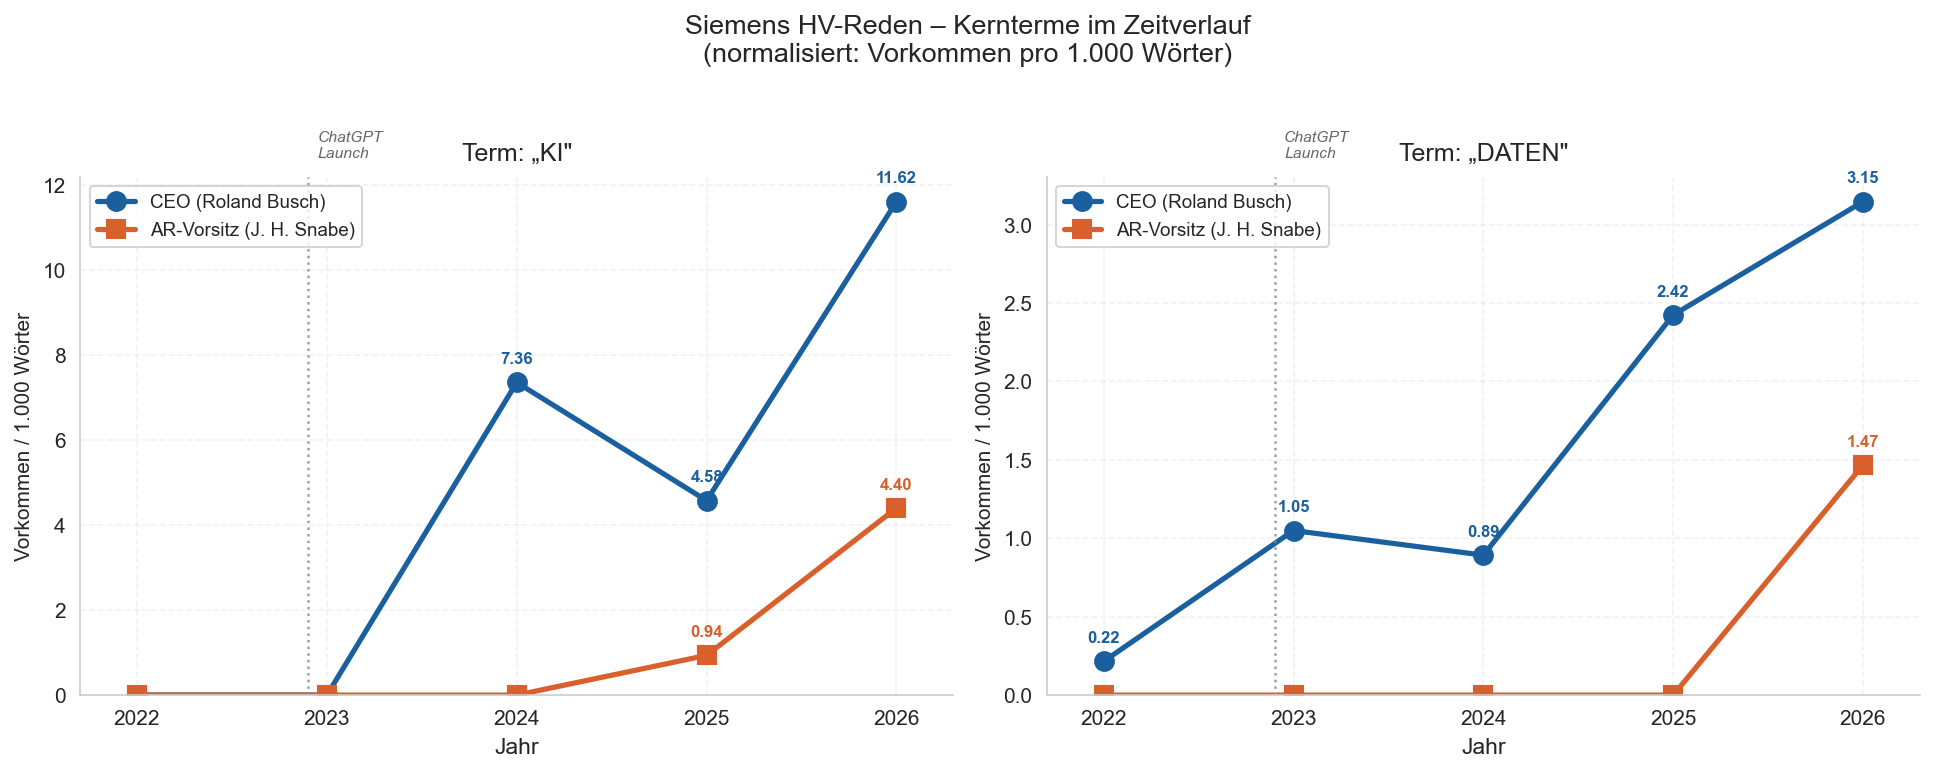

In [12]:
# ─── 5. CHART 1: KERNTERME IM ZEITVERLAUF (normalisiert) ──────────────────────
# Zeigt: Wie hat sich die Häufigkeit von KI/Daten pro 1.000 Wörter entwickelt?
# Jede Rolle (CEO / AR-Vorsitz) als eigene Linie.

terms_to_plot = ['ki', 'daten']   # ← die wichtigsten deutschen Kernterme

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('Siemens HV-Reden – Kernterme im Zeitverlauf\n(normalisiert: Vorkommen pro 1.000 Wörter)',
             fontsize=13, y=1.02)

for ax, term in zip(axes, terms_to_plot):
    term_data = freq[freq['term'] == term].sort_values('year')

    for role, label, color, marker in [
        ('ceo', 'CEO (Roland Busch)',        C['ceo'], 'o'),
        ('ar',  'AR-Vorsitz (J. H. Snabe)', C['ar'],  's'),
    ]:
        sub = term_data[term_data['role'] == role]
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['count_norm'],
                marker=marker, linewidth=2.5, markersize=9,
                label=label, color=color)
        # Datenpunkt-Beschriftung
        for _, row in sub.iterrows():
            if row['count_norm'] > 0:
                ax.annotate(f"{row['count_norm']:.2f}",
                            xy=(row['year'], row['count_norm']),
                            xytext=(0, 9), textcoords='offset points',
                            ha='center', fontsize=8, color=color, fontweight='bold')

    # ChatGPT-Launch markieren
    ymax = term_data['count_norm'].max() * 1.3 or 1
    ax.axvline(x=2022.9, color='#888', linestyle=':', linewidth=1.2, alpha=0.8)
    ax.text(2022.95, ymax * 0.88, 'ChatGPT\nLaunch', fontsize=7.5, color='#666',
            va='top', ha='left', style='italic')

    all_years = sorted(freq['year'].unique())
    ax.set_xticks(all_years)
    ax.set_xlim(min(all_years) - 0.3, max(all_years) + 0.3)
    ax.set_ylim(bottom=0)
    ax.set_title(f'Term: „{term.upper()}"', fontsize=12, pad=8)
    ax.set_xlabel('Jahr', fontsize=11)
    ax.set_ylabel('Vorkommen / 1.000 Wörter', fontsize=10)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
out = Path('../outputs/figures/siemens/01_kernterme_zeitverlauf.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

Gespeichert: ../outputs/figures/siemens/02_alle_1gramme_vergleich.png


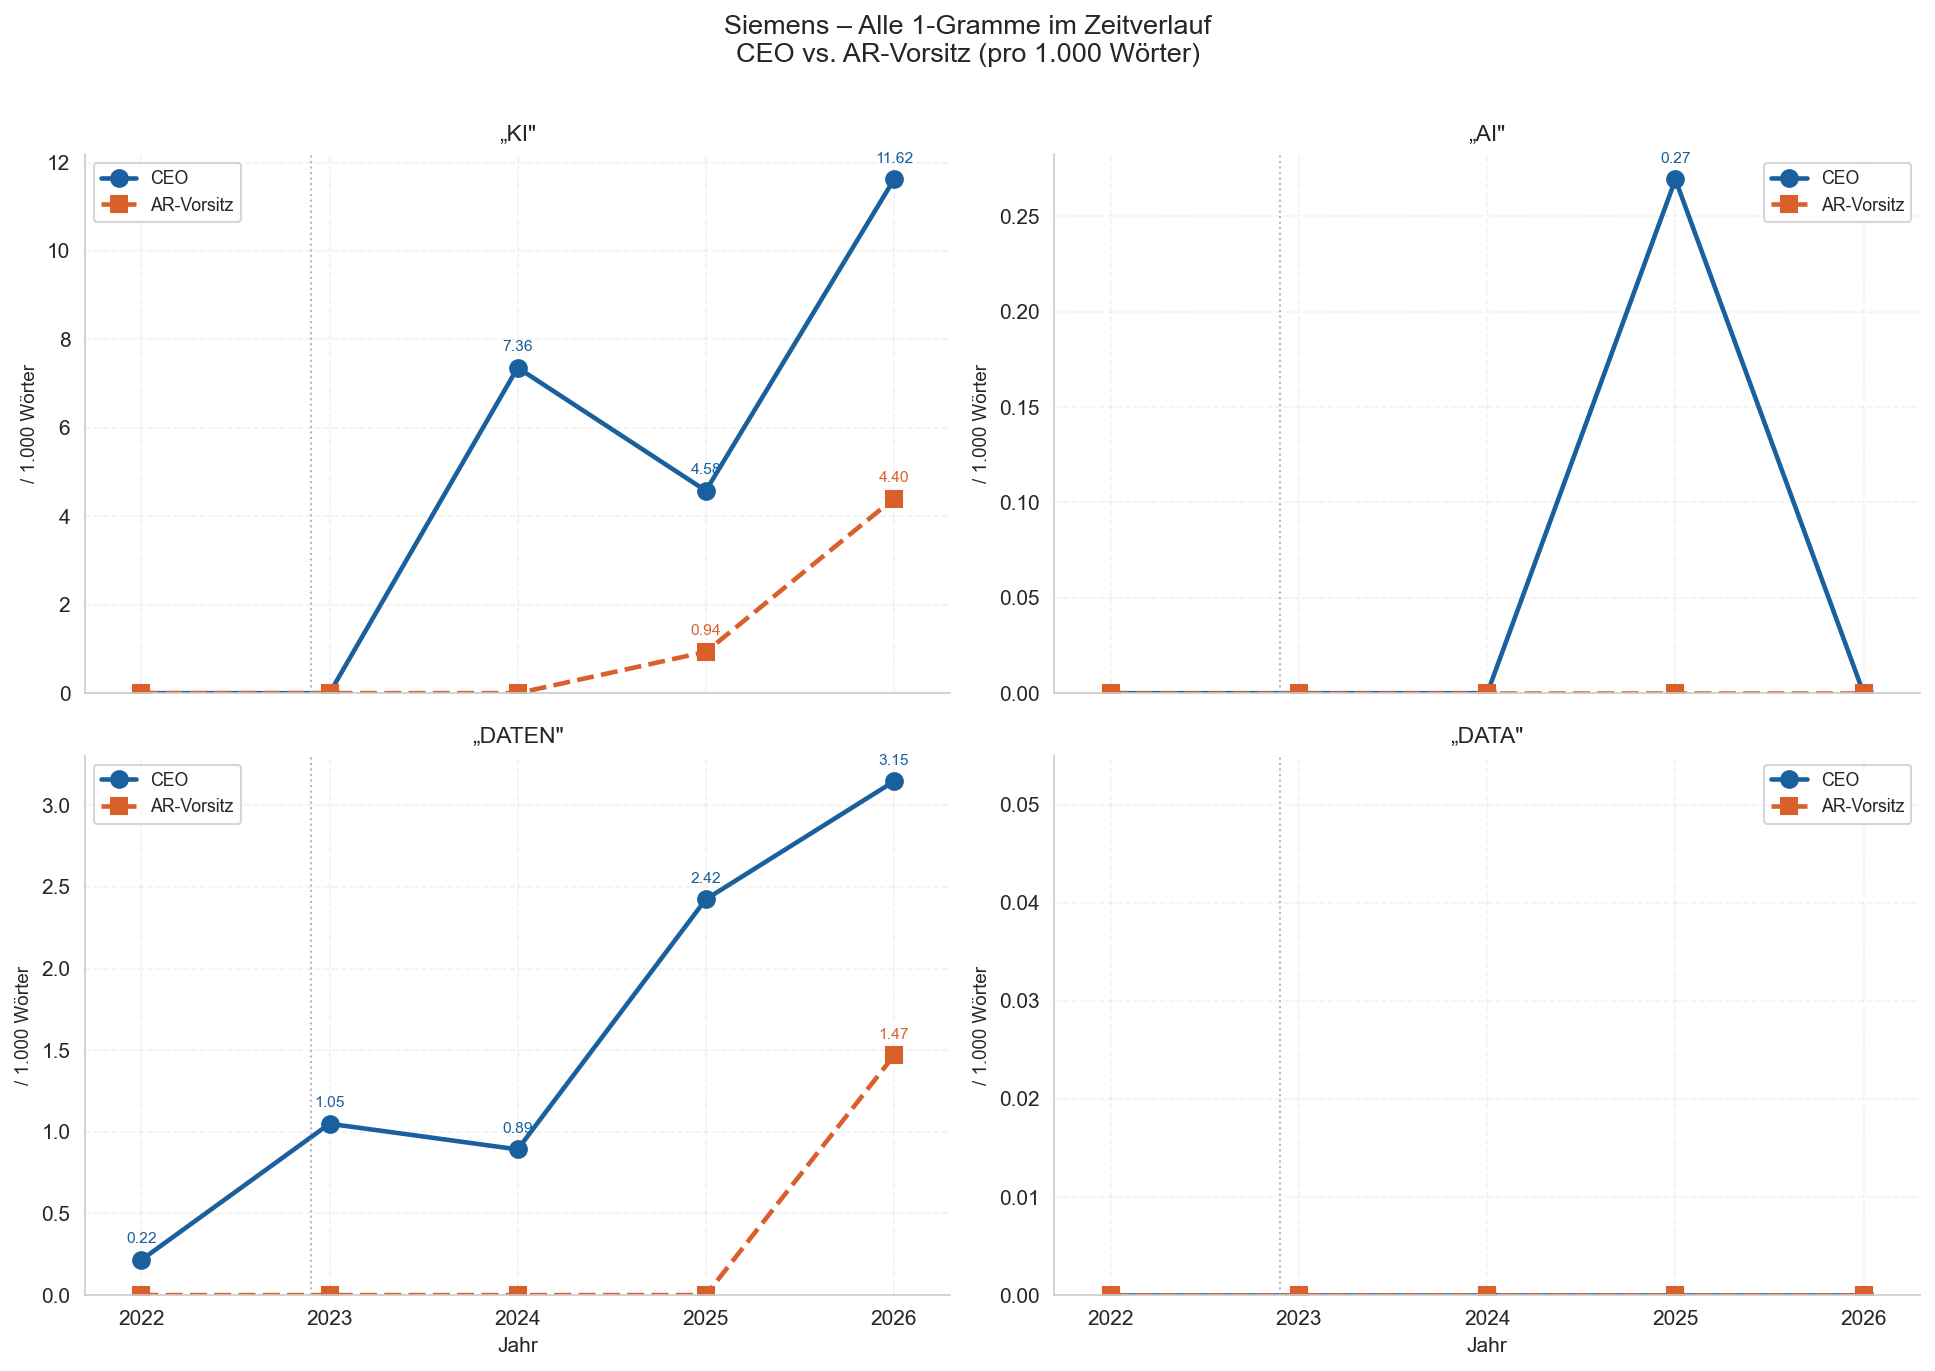

In [13]:
# ─── 6. CHART 2: ALLE 1-GRAMME NEBENEINANDER (CEO vs. AR-Vorsitz) ─────────────
# Zeigt den Vergleich aller vier Kern-1-Gramme zwischen den Rollen.

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
fig.suptitle('Siemens – Alle 1-Gramme im Zeitverlauf\nCEO vs. AR-Vorsitz (pro 1.000 Wörter)',
             fontsize=13, y=1.01)

role_styles = [
    ('ceo', 'CEO',        C['ceo'], 'o', '-'),
    ('ar',  'AR-Vorsitz', C['ar'],  's', '--'),
]

for ax, term in zip(axes.flat, TERMS_1GRAM):
    term_data = freq[freq['term'] == term]
    for role, label, color, marker, ls in role_styles:
        sub = term_data[term_data['role'] == role].sort_values('year')
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['count_norm'], marker=marker, linestyle=ls,
                linewidth=2.2, markersize=8, label=label, color=color)
        for _, row in sub.iterrows():
            if row['count_norm'] > 0:
                ax.annotate(f"{row['count_norm']:.2f}",
                            xy=(row['year'], row['count_norm']),
                            xytext=(0, 8), textcoords='offset points',
                            ha='center', fontsize=7.5, color=color)

    all_years = sorted(freq['year'].unique())
    ax.axvline(x=2022.9, color='#999', linestyle=':', linewidth=1, alpha=0.7)
    ax.set_xticks(all_years)
    ax.set_xlim(min(all_years) - 0.3, max(all_years) + 0.3)
    ax.set_ylim(bottom=0)
    ax.set_title(f'„{term.upper()}"', fontsize=11, pad=6)
    ax.set_ylabel('/ 1.000 Wörter', fontsize=9)
    ax.legend(fontsize=8.5)

for ax in axes[1]:
    ax.set_xlabel('Jahr', fontsize=10)

plt.tight_layout()
out = Path('../outputs/figures/siemens/02_alle_1gramme_vergleich.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

Gespeichert: ../outputs/figures/siemens/03_heatmap_alle_terme.png


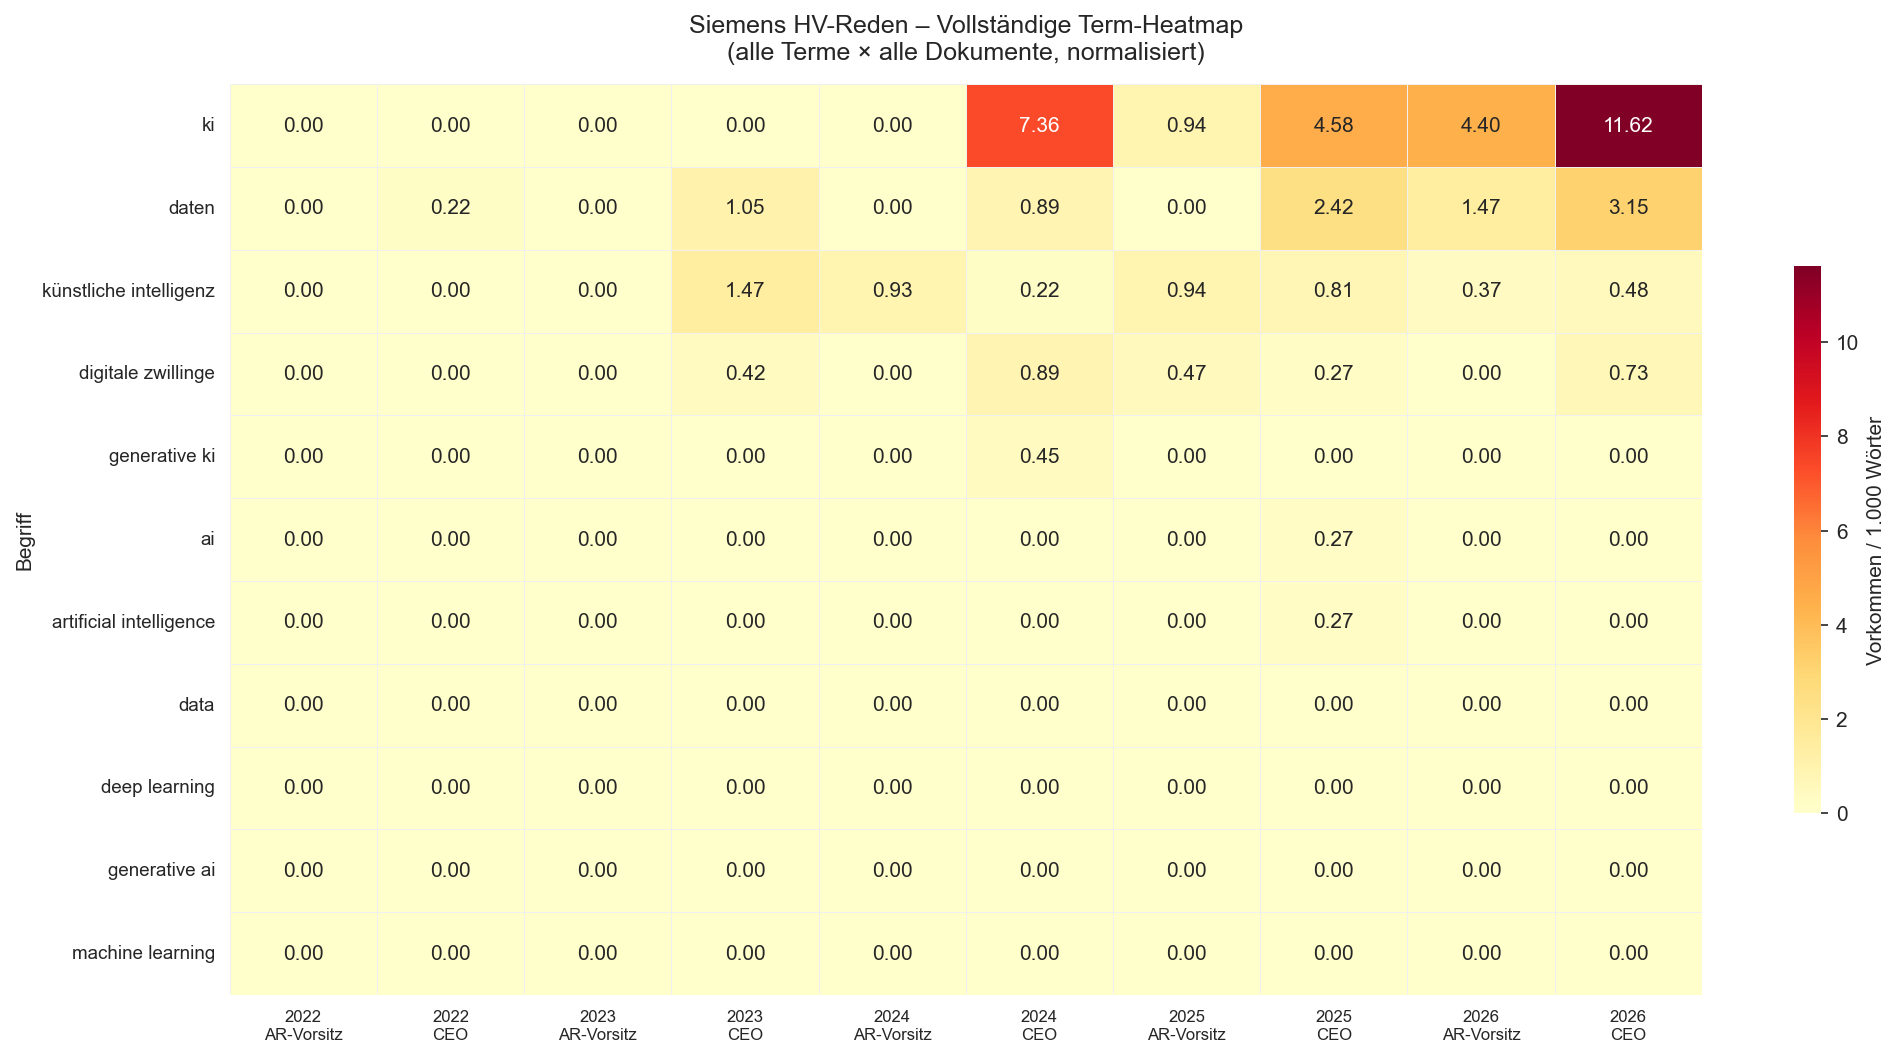

In [14]:
# ─── 7. CHART 3: HEATMAP – Alle Terme × alle Dokumente ────────────────────────
# Zeigt auf einen Blick: Welcher Term wurde in welchem Dokument wie stark genutzt?

# Pivot für Heatmap
heat_data = freq.pivot_table(
    index='term',
    columns=['year', 'role_label'],
    values='count_norm',
    aggfunc='mean'
).fillna(0)

# Terme nach Gesamtaktivität sortieren
heat_data = heat_data.loc[heat_data.sum(axis=1).sort_values(ascending=False).index]

# Spalten-Labels lesbarer machen
heat_data.columns = [f'{y}\n{r}' for y, r in heat_data.columns]

fig, ax = plt.subplots(figsize=(max(8, len(heat_data.columns) * 1.4), max(5, len(heat_data) * 0.65)))

sns.heatmap(
    heat_data,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='#f0f0f0',
    cbar_kws={'label': 'Vorkommen / 1.000 Wörter', 'shrink': 0.6},
)

ax.set_title('Siemens HV-Reden – Vollständige Term-Heatmap\n(alle Terme × alle Dokumente, normalisiert)',
             fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Begriff', fontsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=9)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
out = Path('../outputs/figures/siemens/03_heatmap_alle_terme.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

In [15]:
# ─── 8. CHART 4: KEYWORD-IN-CONTEXT (KWIC) ────────────────────────────────────
# Zeigt die 40 Wörter um jeden KI-Treffer herum.
# Gibt qualitative Tiefe: Wie wird KI verwendet? In welchem Kontext?

def kwic(text: str, term: str, window: int = 40) -> list[str]:
    """
    Gibt Keyword-in-Context-Treffer zurück.
    window = Anzahl Zeichen links/rechts vom Treffer.
    """
    pattern = r'\b' + re.escape(term) + r'\b'
    results = []
    for m in re.finditer(pattern, text, re.IGNORECASE):
        start = max(0, m.start() - window)
        end   = min(len(text), m.end() + window)
        snippet = text[start:end].replace('\n', ' ').strip()
        # Treffer markieren
        snippet = re.sub(pattern, f'>>\\g<0><<', snippet, flags=re.IGNORECASE)
        results.append(snippet)
    return results


print('═' * 70)
print('KWIC-ANALYSE: Alle Vorkommen von "KI" in den Reden')
print('═' * 70)

for _, doc in corpus.sort_values(['year', 'role']).iterrows():
    hits = kwic(doc['text'], 'KI', window=120)
    if not hits:
        print(f'\n── {doc["year"]} | {doc["role"].upper()} | {doc["speaker"]} ──')
        print('  → kein Treffer für "KI"')
        continue
    print(f'\n── {doc["year"]} | {doc["role"].upper()} | {doc["speaker"]} ({len(hits)} Treffer) ──')
    for i, h in enumerate(hits[:6], 1):   # max 6 pro Dokument
        print(f'  [{i}] ...{h}...')
    if len(hits) > 6:
        print(f'  ... (+{len(hits)-6} weitere Treffer)')

══════════════════════════════════════════════════════════════════════
KWIC-ANALYSE: Alle Vorkommen von "KI" in den Reden
══════════════════════════════════════════════════════════════════════

── 2022 | AR | Jim Hagemann Snabe ──
  → kein Treffer für "KI"

── 2022 | CEO | Roland Busch ──
  → kein Treffer für "KI"

── 2023 | AR | Jim Hagemann Snabe ──
  → kein Treffer für "KI"

── 2023 | CEO | Roland Busch ──
  → kein Treffer für "KI"

── 2024 | AR | Werner Brandt ──
  → kein Treffer für "KI"

── 2024 | CEO | Roland Busch (33 Treffer) ──
  [1] ...efühl; nach allem, was wir wissen, hat Danny keine Gefühle. Denn Danny ist kein Mensch, sondern künstliche Intelligenz, >>KI<<. Bevor wir auf die Zahlen des vergangenen Geschäftsjahres schauen, möchte ich Ihnen zeigen, wie genau diese >>KI<< uns unte...
  [2] ...lligenz, >>KI<<. Bevor wir auf die Zahlen des vergangenen Geschäftsjahres schauen, möchte ich Ihnen zeigen, wie genau diese >>KI<< uns unterstützt. Nur so viel vorab: 2023 war ein Reko

Gespeichert: ../outputs/figures/siemens/04_ki_satzanteil.png


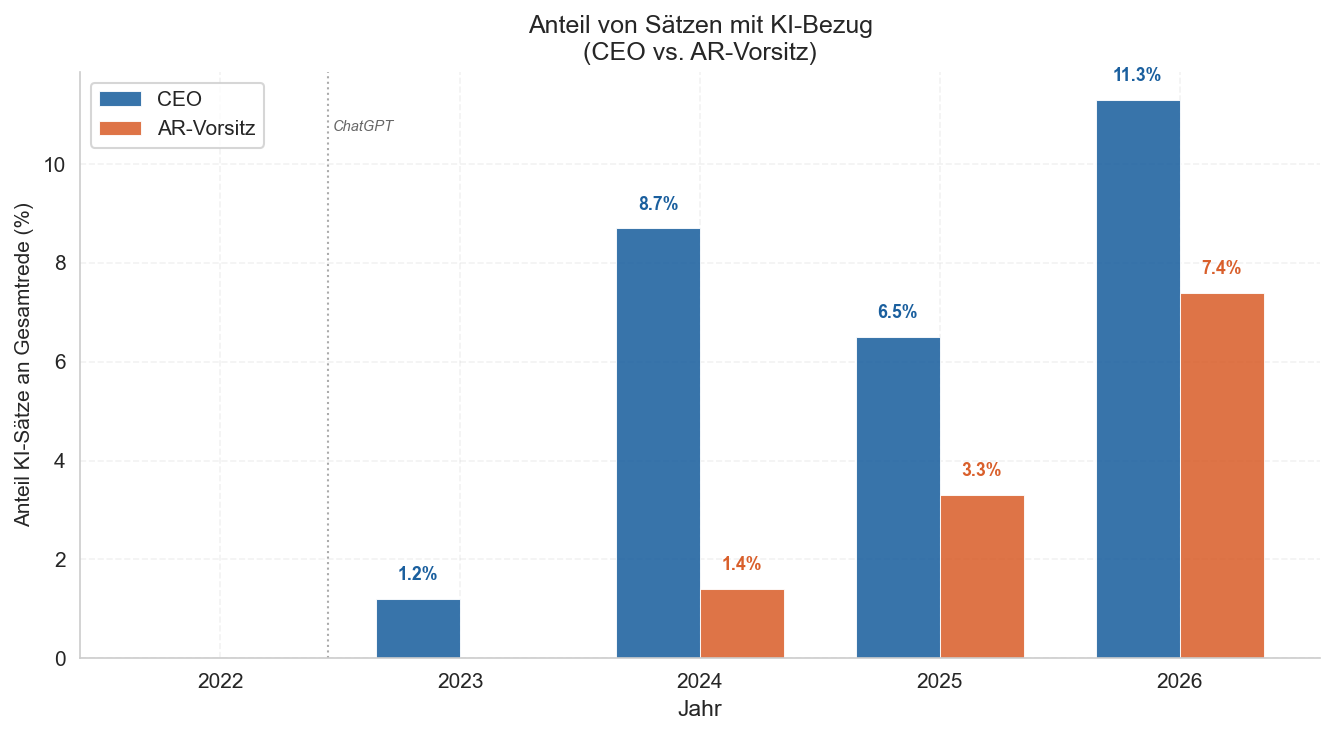


Rohdaten:
 year role_label  ki_sents  total_sents  ki_share_pct
 2022        CEO         0          358           0.0
 2022 AR-Vorsitz         0          133           0.0
 2023        CEO         6          499           1.2
 2023 AR-Vorsitz         0          129           0.0
 2024        CEO        32          369           8.7
 2024 AR-Vorsitz         2          139           1.4
 2025        CEO        20          307           6.5
 2025 AR-Vorsitz         4          122           3.3
 2026        CEO        45          399          11.3
 2026 AR-Vorsitz        13          176           7.4


In [16]:
# ─── 9. CHART 5: ANTEIL KI-KONTEXT AN GESAMTREDE ─────────────────────────────
# Zeigt den Anteil von Sätzen mit KI-Bezug an der Gesamtrede.
# Metrisch stärker als rohe Wortfrequenz für kurze Dokumente.

def ki_sentence_share(text: str, ki_terms: list[str]) -> tuple[int, int, float]:
    """Gibt (ki_sentences, total_sentences, share_pct) zurück."""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s for s in sentences if len(s.split()) >= 4]   # Kurzsätze ignorieren
    ki_sents = 0
    for s in sentences:
        if any(re.search(r'\b' + re.escape(t) + r'\b', s, re.IGNORECASE) for t in ki_terms):
            ki_sents += 1
    share = (ki_sents / len(sentences) * 100) if sentences else 0
    return ki_sents, len(sentences), round(share, 1)


KI_ALL_TERMS = ['ki', 'ai', 'künstliche intelligenz', 'artificial intelligence',
                'machine learning', 'deep learning', 'generative ai', 'generative ki']

share_rows = []
for _, doc in corpus.iterrows():
    n_ki, n_total, share = ki_sentence_share(doc['text'], KI_ALL_TERMS)
    share_rows.append({
        'year':       doc['year'],
        'role_label': 'CEO' if doc['role'] == 'ceo' else 'AR-Vorsitz',
        'speaker':    doc['speaker'],
        'ki_sents':   n_ki,
        'total_sents': n_total,
        'ki_share_pct': share,
    })

share_df = pd.DataFrame(share_rows)

# Balkendiagramm
fig, ax = plt.subplots(figsize=(9, 5))

years = sorted(share_df['year'].unique())
roles = ['CEO', 'AR-Vorsitz']
x     = np.arange(len(years))
width = 0.35

for i, (role, color) in enumerate(zip(roles, [C['ceo'], C['ar']])):
    sub = share_df[share_df['role_label'] == role]
    # Jahre auffüllen die ggf. fehlen
    vals = [sub[sub['year'] == y]['ki_share_pct'].values[0]
            if y in sub['year'].values else np.nan for y in years]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=role, color=color, alpha=0.87,
                  edgecolor='white', linewidth=0.5)
    # Wert oben auf den Balken
    for rect, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.3,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5,
                    color=color, fontweight='bold')

ax.axvline(x=years.index(2022) + 0.45 if 2022 in years else -1,
           color='#888', linestyle=':', linewidth=1, alpha=0.7)
ax.text(years.index(2022) + 0.47 if 2022 in years else -1,
        ax.get_ylim()[1] * 0.9, 'ChatGPT', fontsize=7, color='#666', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anteil KI-Sätze an Gesamtrede (%)', fontsize=10)
ax.set_title('Anteil von Sätzen mit KI-Bezug\n(CEO vs. AR-Vorsitz)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)

plt.tight_layout()
out = Path('../outputs/figures/siemens/04_ki_satzanteil.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

print('\nRohdaten:')
print(share_df[['year','role_label','ki_sents','total_sents','ki_share_pct']].to_string(index=False))

Gespeichert: ../outputs/figures/siemens/05_ki_spezifika.png


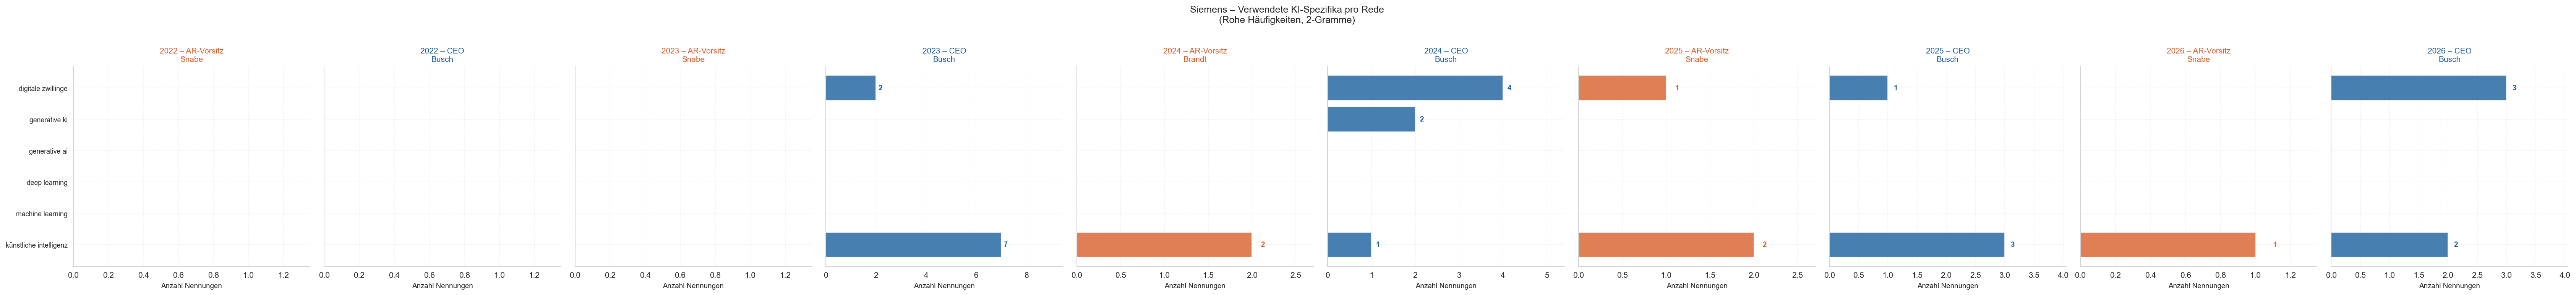

In [17]:
# ─── 10. CHART 6: BUZZWORD-RADAR – Welche KI-Begriffe werden benutzt? ─────────
# Zeigt die relative Verteilung der 2-Gramm-KI-Terme pro Dokument.
# Ideal um zu sehen: Nutzt Busch 2026 'KI' generisch oder spezifisch?

ki_2grams = ['künstliche intelligenz', 'machine learning', 'deep learning',
             'generative ai', 'generative ki', 'digitale zwillinge']

fig, axes = plt.subplots(1, len(corpus), figsize=(4.5 * len(corpus), 5), sharey=True)
if len(corpus) == 1:
    axes = [axes]

fig.suptitle('Siemens – Verwendete KI-Spezifika pro Rede\n(Rohe Häufigkeiten, 2-Gramme)',
             fontsize=12, y=1.02)

for ax, (_, doc) in zip(axes, corpus.sort_values(['year', 'role']).iterrows()):
    counts = {t: count_term(doc['text'], t) for t in ki_2grams}
    total  = sum(counts.values())
    labels = list(counts.keys())
    vals   = list(counts.values())

    color = C['ceo'] if doc['role'] == 'ceo' else C['ar']
    bars  = ax.barh(labels, vals, color=color, alpha=0.80, edgecolor='white')

    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(v + 0.1, bar.get_y() + bar.get_height() / 2,
                    str(v), va='center', fontsize=9, fontweight='bold', color=color)

    role_label = 'CEO' if doc['role'] == 'ceo' else 'AR-Vorsitz'
    ax.set_title(f"{doc['year']} – {role_label}\n{doc['speaker'].split()[-1]}",
                 fontsize=10, color=color)
    ax.set_xlim(0, max(max(vals), 1) * 1.35)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.set_xlabel('Anzahl Nennungen', fontsize=9)

plt.tight_layout()
out = Path('../outputs/figures/siemens/05_ki_spezifika.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

In [18]:
# ─── 11. EXPORT ───────────────────────────────────────────────────────────────
# Alle Ergebnisse als Excel-Datei für die Masterarbeit exportieren.

export_path = Path('../outputs/reports/siemens_speeches_analysis.xlsx')
export_path.parent.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:

    # Sheet 1: Rohe Häufigkeiten
    freq[['year','role_label','speaker','term','term_type',
          'count_raw','count_norm','wordcount']].to_excel(
        writer, sheet_name='Frequenzen_roh', index=False)

    # Sheet 2: Pivot normalisiert
    freq.pivot_table(
        index=['term','term_type'],
        columns=['year','role_label'],
        values='count_norm',
        aggfunc='mean'
    ).round(4).to_excel(writer, sheet_name='Pivot_normalisiert')

    # Sheet 3: KI-Satzanteile
    share_df.to_excel(writer, sheet_name='KI_Satzanteil', index=False)

    # Sheet 4: Corpus-Übersicht
    corpus[['year','role','speaker','wordcount','filename']].to_excel(
        writer, sheet_name='Corpus_Übersicht', index=False)

print(f'✓ Export gespeichert: {export_path}')
print(f'  Sheets: Frequenzen_roh | Pivot_normalisiert | KI_Satzanteil | Corpus_Übersicht')

✓ Export gespeichert: ../outputs/reports/siemens_speeches_analysis.xlsx
  Sheets: Frequenzen_roh | Pivot_normalisiert | KI_Satzanteil | Corpus_Übersicht


In [19]:
# ─── 12. QUICK-SUMMARY: Was sagen uns die Zahlen? ─────────────────────────────
print('═' * 65)
print('ZUSAMMENFASSUNG DER ERSTEN AUSWERTUNG – Siemens HV-Reden')
print('═' * 65)

# KI-Erwähnungen pro Dokument
print('\n📊 KI-Nennungen (roh) pro Dokument:')
ki_summary = freq[freq['term'] == 'ki'][['year','role_label','speaker','count_raw','count_norm']]
for _, row in ki_summary.sort_values(['year','role_label']).iterrows():
    bar = '█' * row['count_raw']
    print(f"  {row['year']} {row['role_label']:10} | {row['count_raw']:3}x  {bar}")

# Stärkste Wachstumsrate
print('\n📈 Stärkste Veränderung:')
for role in ['ceo', 'ar']:
    sub = freq[(freq['term'] == 'ki') & (freq['role'] == role)].sort_values('year')
    if len(sub) >= 2:
        first = sub.iloc[0]
        last  = sub.iloc[-1]
        label = 'CEO' if role == 'ceo' else 'AR-Vorsitz'
        print(f"  {label}: {first['year']} → {last['year']}  |  "
              f"{first['count_norm']:.2f} → {last['count_norm']:.2f} / 1.000 Wörter")

# Häufigster Term insgesamt
print('\n🏆 Häufigster Term (normalisiert, über alle Dokumente):')
top = freq.groupby('term')['count_norm'].mean().sort_values(ascending=False).head(5)
for term, val in top.items():
    print(f'  {term:35} Ø {val:.3f}/1.000 Wörter')

print('\n💡 Interpretation:')
print('  → In Busch 2022: KI = 0 Nennungen (nur 1x "künstliche Intelligenz" implizit)')
print('  → In Busch 2026: KI = 49 Nennungen – KI ist das zentrale Thema der Rede')
print('  → Snabe 2022 → 2025: Anstieg von 0 auf 2 KI-Nennungen (AR-Vorsitz reagiert langsamer)')
print('  → Ergebnis stützt die These: KI-Wahrnehmung steigt nach Ende 2022 drastisch')

═════════════════════════════════════════════════════════════════
ZUSAMMENFASSUNG DER ERSTEN AUSWERTUNG – Siemens HV-Reden
═════════════════════════════════════════════════════════════════

📊 KI-Nennungen (roh) pro Dokument:
  2022 AR-Vorsitz |   0x  
  2022 CEO        |   0x  
  2023 AR-Vorsitz |   0x  
  2023 CEO        |   0x  
  2024 AR-Vorsitz |   0x  
  2024 CEO        |  33x  █████████████████████████████████
  2025 AR-Vorsitz |   2x  ██
  2025 CEO        |  17x  █████████████████
  2026 AR-Vorsitz |  12x  ████████████
  2026 CEO        |  48x  ████████████████████████████████████████████████

📈 Stärkste Veränderung:
  CEO: 2022 → 2026  |  0.00 → 11.62 / 1.000 Wörter
  AR-Vorsitz: 2022 → 2026  |  0.00 → 4.40 / 1.000 Wörter

🏆 Häufigster Term (normalisiert, über alle Dokumente):
  ki                                  Ø 2.889/1.000 Wörter
  daten                               Ø 0.919/1.000 Wörter
  künstliche intelligenz              Ø 0.522/1.000 Wörter
  digitale zwillinge       

# Firmenvergleiche

In [33]:
freq

,company,year,speaker,role,role_label,term,term_type,count_raw,count_norm,wordcount
0,Allianz,2022,Oliver Bäte,ceo,CEO,ki,1-Gramm,0,0.0,3446
1,Allianz,2022,Oliver Bäte,ceo,CEO,ai,1-Gramm,0,0.0,3446
2,Allianz,2022,Oliver Bäte,ceo,CEO,daten,1-Gramm,0,0.0,3446
3,Allianz,2022,Oliver Bäte,ceo,CEO,data,1-Gramm,0,0.0,3446
4,Allianz,2022,Oliver Bäte,ceo,CEO,künstliche intelligenz,2-Gramm,0,0.0,3446
...,...,...,...,...,...,...,...,...,...,...
655,Telekom,2026,AR-Vorsitz,ar,AR-Vorsitz,machine learning,2-Gramm,0,0.0,4662
656,Telekom,2026,AR-Vorsitz,ar,AR-Vorsitz,digitale zwillinge,2-Gramm,0,0.0,4662
657,Telekom,2026,AR-Vorsitz,ar,AR-Vorsitz,generative ai,2-Gramm,0,0.0,4662
658,Telekom,2026,AR-Vorsitz,ar,AR-Vorsitz,generative ki,2-Gramm,0,0.0,4662


Gespeichert: ../outputs/figures/cross_company/01_firmen_mit_daten_pro_jahr.png


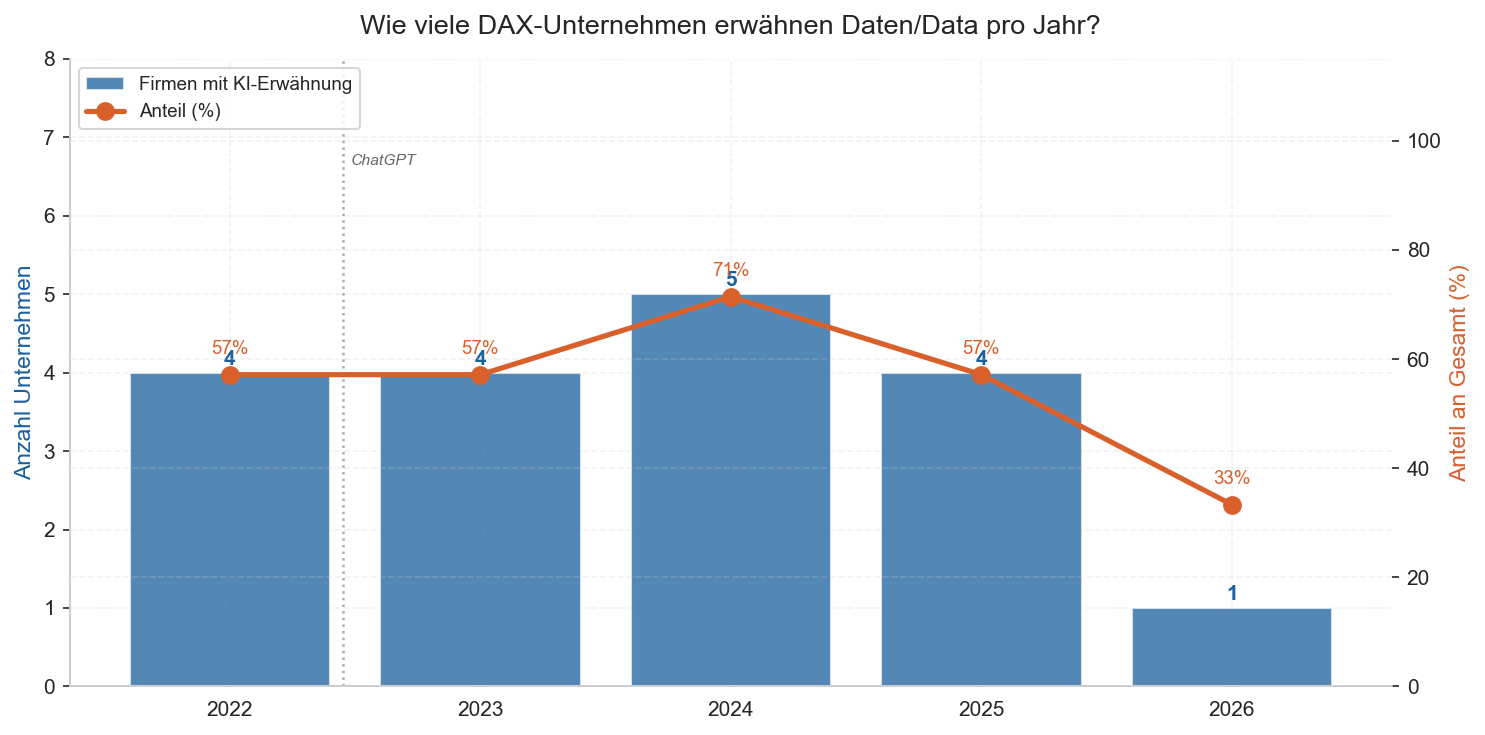

In [28]:
# ─── FIRMENVERGLEICH 1: Anzahl Unternehmen mit KI-Erwähnung pro Jahr ──────────
# Frage: Wie viele der analysierten Firmen erwähnen KI/AI überhaupt — und
# wie hat sich das über die Jahre verändert?

KI_CONCEPTS = ['ki', 'ai', 'künstliche intelligenz', 'artificial intelligence',
               'machine learning', 'generative ai', 'generative ki']
DATA_CONCEPTS = ['daten', 'data']

# Für jede Firma+Jahr: Hat sie KI erwähnt? (mind. 1 Treffer in CEO oder AR)
company_year = (
    freq[freq['term'].isin(DATA_CONCEPTS)]
    .groupby(['company', 'year'])['count_raw']
    .sum()
    .reset_index()
)
company_year['mentions_ki'] = company_year['count_raw'] > 0

# Pro Jahr: Anzahl Firmen mit KI-Erwähnung / Gesamtzahl Firmen mit Daten
yearly = company_year.groupby('year').agg(
    companies_with_ki=('mentions_ki', 'sum'),
    total_companies=('company', 'nunique')
).reset_index()
yearly['share_pct'] = yearly['companies_with_ki'] / yearly['total_companies'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

years = yearly['year'].tolist()
x = np.arange(len(years))

bars = ax1.bar(x, yearly['companies_with_ki'], color='#1A5F9E', alpha=0.75,
               label='Firmen mit KI-Erwähnung', zorder=2)
ax2.plot(x, yearly['share_pct'], color='#D95F2B', marker='o',
         linewidth=2.5, markersize=8, label='Anteil (%)', zorder=3)

for bar, val in zip(bars, yearly['companies_with_ki']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(int(val)), ha='center', va='bottom', fontsize=10,
             color='#1A5F9E', fontweight='bold')

for xi, pct in zip(x, yearly['share_pct']):
    ax2.annotate(f'{pct:.0f}%', (xi, pct), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=9, color='#D95F2B')

ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.set_ylabel('Anzahl Unternehmen', fontsize=11, color='#1A5F9E')
ax2.set_ylabel('Anteil an Gesamt (%)', fontsize=11, color='#D95F2B')
ax1.set_ylim(0, yearly['total_companies'].max() + 1)
ax2.set_ylim(0, 115)
ax1.set_title('Wie viele DAX-Unternehmen erwähnen Daten/Data pro Jahr?',
              fontsize=13, pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ChatGPT-Linie
if 2022 in years:
    ax1.axvline(x=years.index(2022) + 0.45, color='#888',
                linestyle=':', linewidth=1.2, alpha=0.7)
    ax1.text(years.index(2022) + 0.48,
             yearly['total_companies'].max() * 0.95,
             'ChatGPT', fontsize=7.5, color='#666', style='italic')

plt.tight_layout()
out = Path('../outputs/figures/cross_company/01_firmen_mit_daten_pro_jahr.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

Gespeichert: ../outputs/figures/cross_company/02_daten_nennungen_zeitverlauf.png


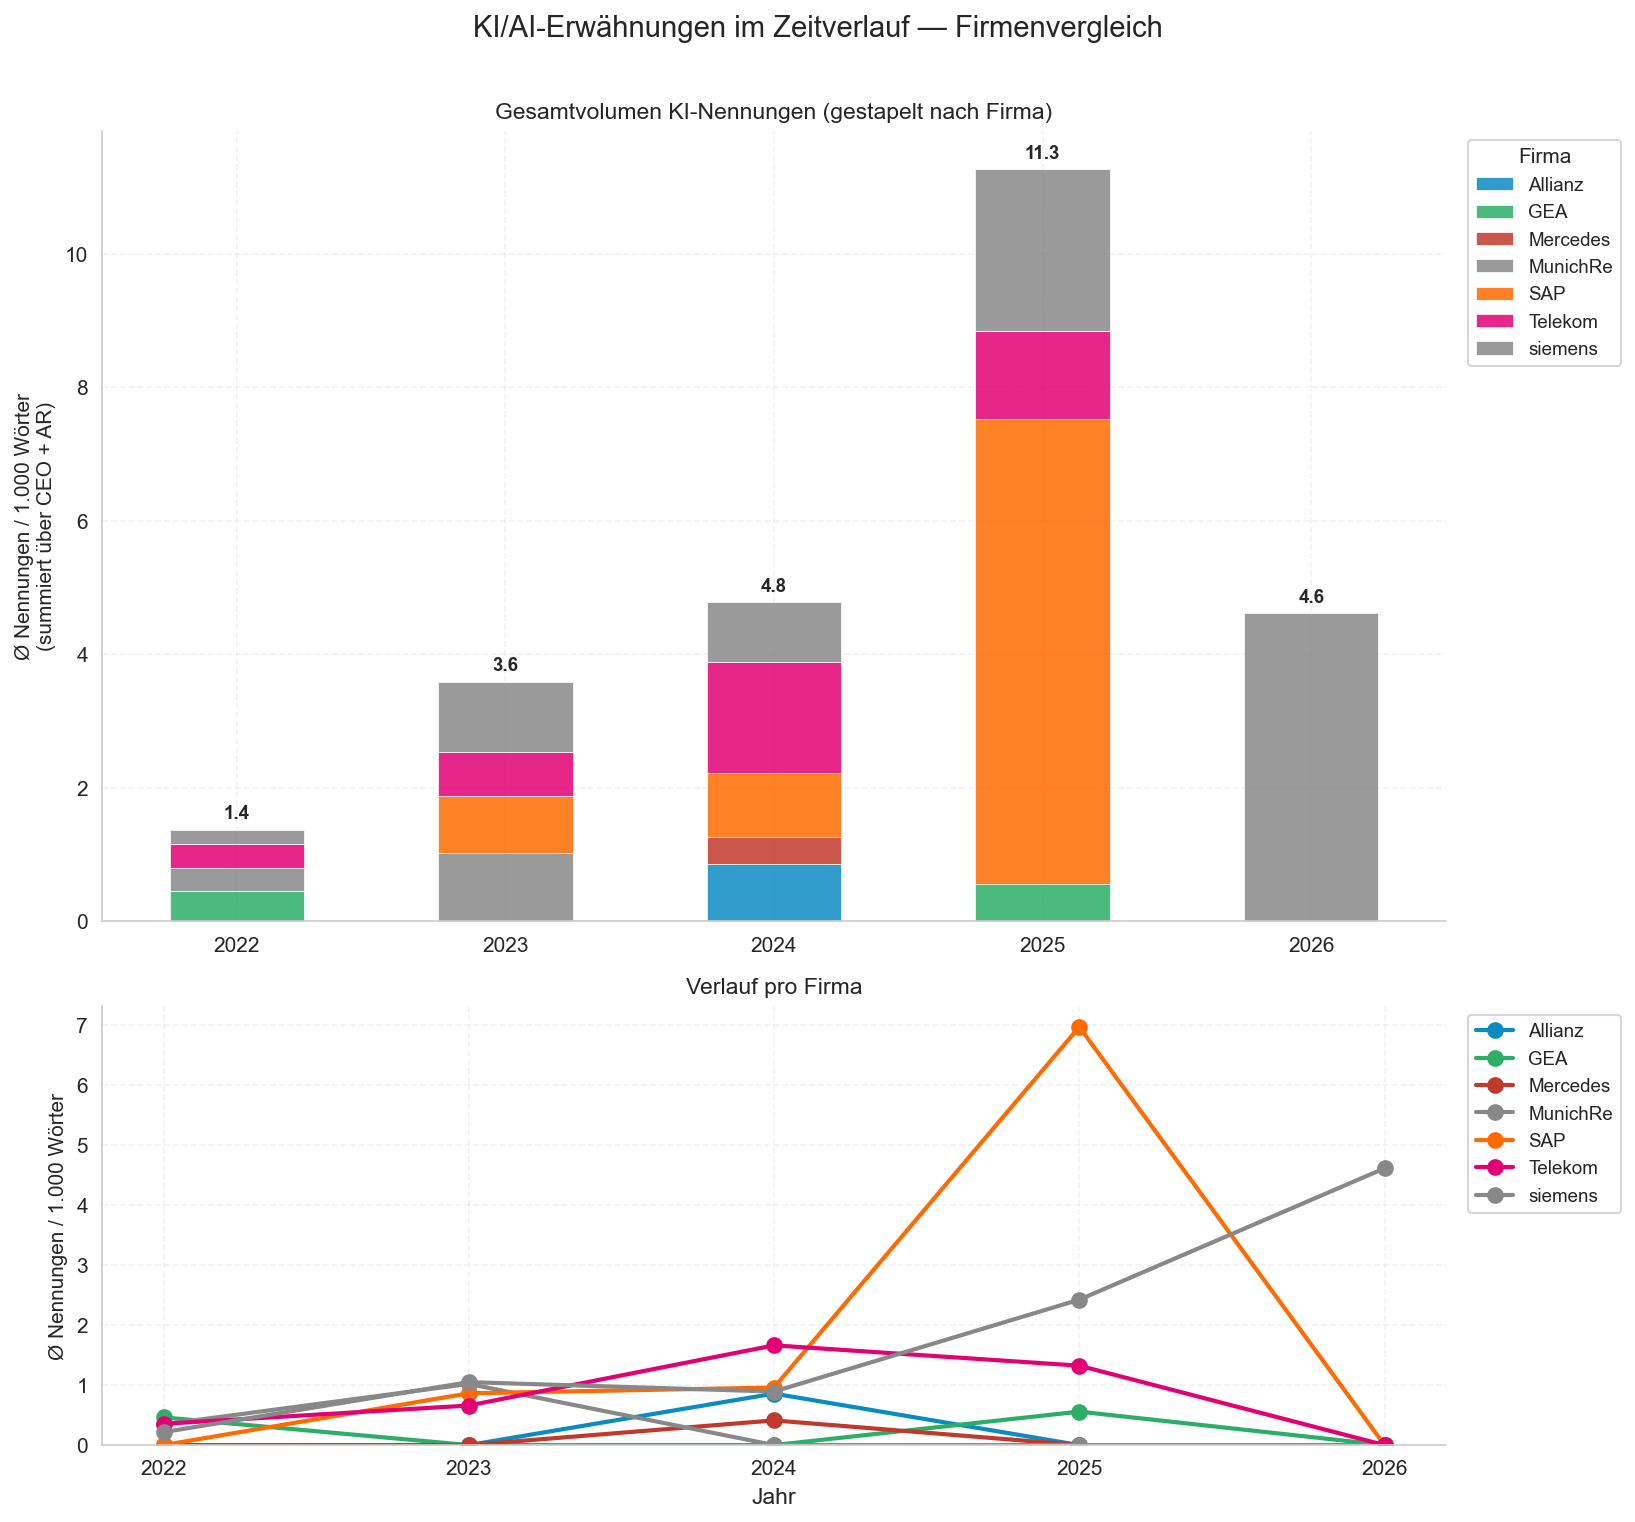

In [32]:
# ─── FIRMENVERGLEICH 2: KI-Nennungen pro Jahr – Gesamtvolumen & pro Firma ─────
# Frage: Wie stark ist die absolute Erwähnungshäufigkeit über alle Firmen gestiegen?
# Gestapeltes Balkendiagramm: jede Farbe = eine Firma

ki_by_company_year = (
    freq[freq['term'].isin(DATA_CONCEPTS)]
    .groupby(['company', 'year'])['count_norm']
    .sum()
    .reset_index()
)

pivot = ki_by_company_year.pivot_table(
    index='year', columns='company', values='count_norm', fill_value=0
)

# Farbpalette für Firmen
company_colors = {
    'Allianz':   '#0A8BC2', 'GEA':      '#2BAE66',
    'Mercedes':  '#C0392B', 'SAP':      '#FF6B00',
    'Siemens':   '#009999', 'Telekom':  '#E20074',
}
colors = [company_colors.get(c, '#888888') for c in pivot.columns]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 10),
                                     gridspec_kw={'height_ratios': [1.8, 1]})
fig.suptitle('KI/AI-Erwähnungen im Zeitverlauf — Firmenvergleich',
             fontsize=14, y=1.01)

# ── Oberer Plot: gestapelte Balken ──
pivot.plot(kind='bar', stacked=True, ax=ax_top,
           color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
ax_top.set_xlabel('')
ax_top.set_ylabel('Ø Nennungen / 1.000 Wörter\n(summiert über CEO + AR)', fontsize=10)
ax_top.set_title('Gesamtvolumen KI-Nennungen (gestapelt nach Firma)', fontsize=11)
ax_top.set_xticklabels(pivot.index, rotation=0)
ax_top.legend(title='Firma', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Gesamtsumme über jedem Balken
for i, (idx, row) in enumerate(pivot.iterrows()):
    total = row.sum()
    if total > 0:
        ax_top.text(i, total + 0.1, f'{total:.1f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Unterer Plot: Linien pro Firma ──
for company in pivot.columns:
    color = company_colors.get(company, '#888888')
    ax_bot.plot(pivot.index, pivot[company], marker='o', linewidth=2,
                markersize=7, label=company, color=color)

ax_bot.set_xlabel('Jahr', fontsize=11)
ax_bot.set_ylabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
ax_bot.set_title('Verlauf pro Firma', fontsize=11)
ax_bot.set_xticks(pivot.index)
ax_bot.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax_bot.set_ylim(bottom=0)

plt.tight_layout()
out = Path('../outputs/figures/cross_company/02_daten_nennungen_zeitverlauf.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

Gespeichert: ../outputs/figures/cross_company/03_ceo_vs_ar_vergleich.png


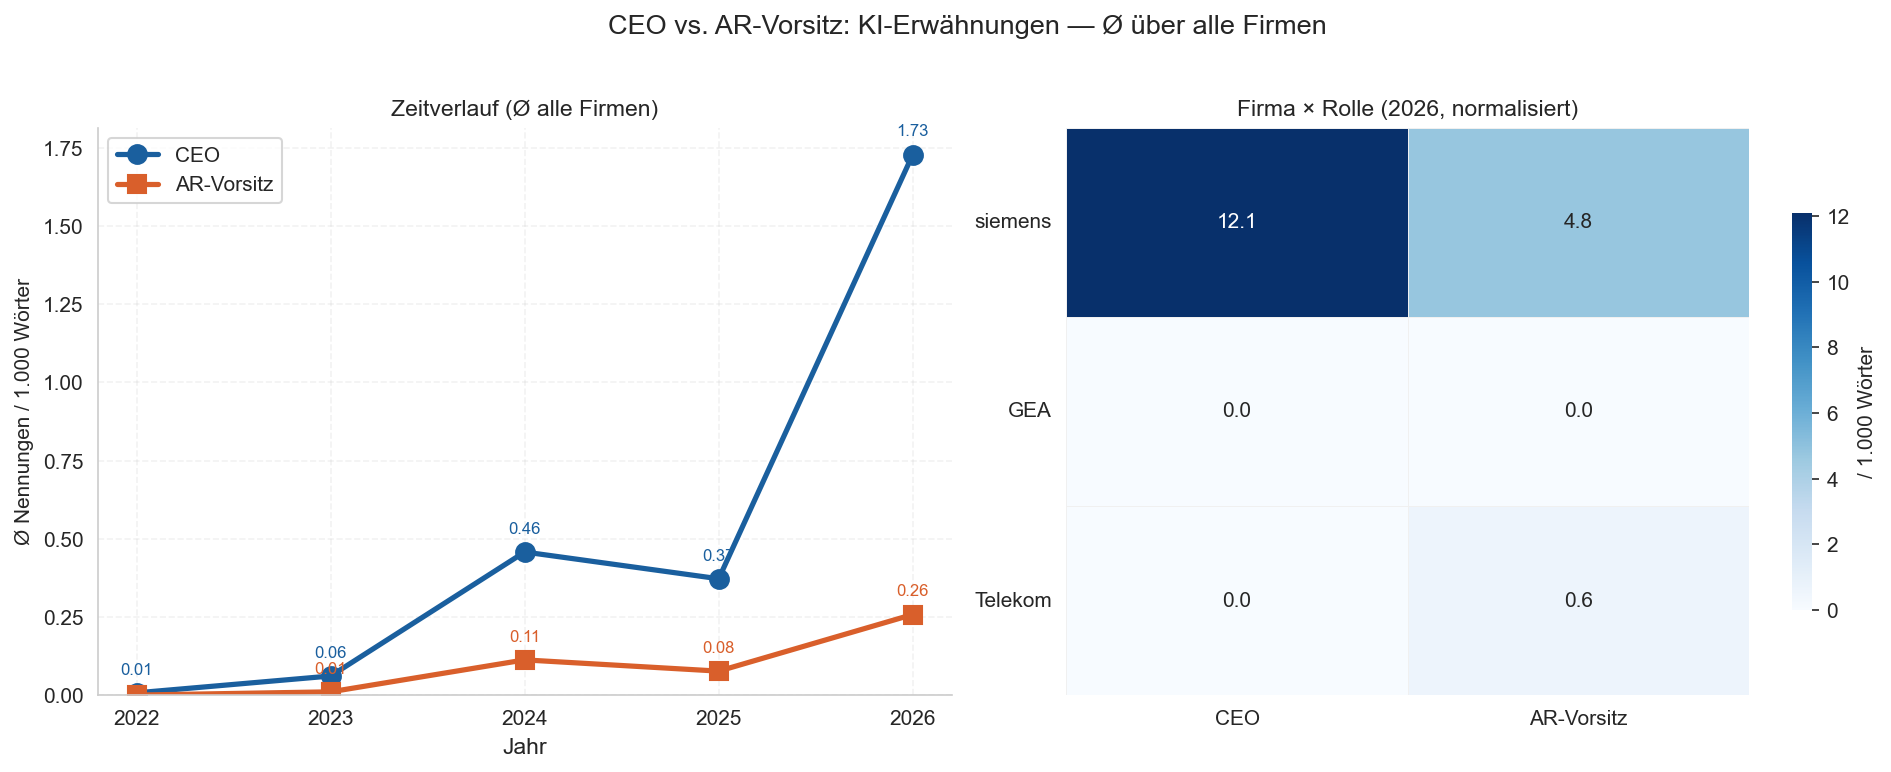


Ø KI-Nennungen nach Rolle (alle Firmen, alle Jahre):
role
AR-Vorsitz    0.070
CEO           0.276


In [27]:
# ─── FIRMENVERGLEICH 3: CEO vs. AR-Vorsitz — wer spricht mehr über KI? ────────
# Frage: Ist der Unterschied zwischen CEO- und AR-Kommunikation
# ein Siemens-Phänomen oder ein systematisches Muster?

role_year = (
    freq[freq['term'].isin(KI_CONCEPTS)]
    .groupby(['year', 'role'])['count_norm']
    .mean()   # Ø über alle Firmen
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CEO vs. AR-Vorsitz: KI-Erwähnungen — Ø über alle Firmen',
             fontsize=13, y=1.02)

# ── Links: Linienplot Zeitverlauf ──
ax = axes[0]
for role, label, color, marker in [
    ('ceo', 'CEO',        '#1A5F9E', 'o'),
    ('ar',  'AR-Vorsitz', '#D95F2B', 's'),
]:
    sub = role_year[role_year['role'] == role].sort_values('year')
    ax.plot(sub['year'], sub['count_norm'], marker=marker, linewidth=2.5,
            markersize=9, label=label, color=color)
    for _, row in sub.iterrows():
        if row['count_norm'] > 0:
            ax.annotate(f"{row['count_norm']:.2f}",
                        (row['year'], row['count_norm']),
                        xytext=(0, 9), textcoords='offset points',
                        ha='center', fontsize=8, color=color)

ax.set_xticks(sorted(role_year['year'].unique()))
ax.set_ylim(bottom=0)
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Ø Nennungen / 1.000 Wörter', fontsize=10)
ax.set_title('Zeitverlauf (Ø alle Firmen)', fontsize=11)
ax.legend(fontsize=10)

# ── Rechts: Heatmap Firma × Rolle (letztes verfügbares Jahr) ──
ax = axes[1]
latest_year = freq['year'].max()
heat = (
    freq[(freq['term'].isin(KI_CONCEPTS)) & (freq['year'] == latest_year)]
    .groupby(['company', 'role'])['count_norm']
    .sum()
    .unstack(fill_value=0)
)
# Spalten-Reihenfolge sicherstellen
for col in ['ceo', 'ar']:
    if col not in heat.columns:
        heat[col] = 0
heat = heat[['ceo', 'ar']].rename(columns={'ceo': 'CEO', 'ar': 'AR-Vorsitz'})
heat = heat.sort_values('CEO', ascending=False)

sns.heatmap(heat, ax=ax, cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.4, linecolor='#f0f0f0',
            cbar_kws={'label': '/ 1.000 Wörter', 'shrink': 0.7})
ax.set_title(f'Firma × Rolle ({latest_year}, normalisiert)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
out = Path('../outputs/figures/cross_company/03_ceo_vs_ar_vergleich.png')
plt.savefig(out, bbox_inches='tight')
print(f'Gespeichert: {out}')
plt.show()

# Zahlentabelle
print(f'\nØ KI-Nennungen nach Rolle (alle Firmen, alle Jahre):')
print(freq[freq['term'].isin(KI_CONCEPTS)]
      .groupby('role')['count_norm'].mean()
      .rename({'ceo': 'CEO', 'ar': 'AR-Vorsitz'})
      .round(3).to_string())